# Imports

In [32]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
%matplotlib inline

## Loading the Dataset



In [28]:
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

## Creating Features and Target Variable

The dataset is separated into:

- Features `X`: independent variables used for prediction
- Target `y`: continuous output variable to be predicted


In [29]:
X=pd.DataFrame(data.data,columns=data.feature_names)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [30]:
y=pd.DataFrame(data.target, columns=['target'])
y.tail()

,target
564,0
565,0
566,0
567,0
568,1


## Exploratory Data Analysis


In [14]:
X.shape

(569, 30)

In [15]:
#Distribution of y-variable
y.value_counts()

target
1         357
0         212
Name: count, dtype: int64

In [16]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [18]:
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

## Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to train the model
- Testing data is used to evaluate performance on unseen data

This helps measure how well the model generalizes.

In [19]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [21]:
X_train.shape

(455, 30)

In [22]:
X_test.shape

(114, 30)

## XGBoost Classifier

In [33]:
model=XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42,
    eval_metrics='logloss'
)

## Model Training

The XGBoost regression model is trained using the training dataset.

During training, the model learns relationships between input features and the continuous target variable.

In [34]:
model.fit(X_train,y_train)

/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:25:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Prediction


In [36]:
y_pred=model.predict(X_test)

In [38]:
y_pred[:10]

array([1, 1, 0, 0, 1, 0, 1, 0, 0, 0])

In [40]:
y_test[:10]

,target
458,1
224,1
28,0
172,0
278,1
121,0
307,1
323,0
533,0
207,0


In [39]:
X_test[:10]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
458,13.00,25.13,82.61,520.2,0.08369,0.05073,0.012060,0.017620,0.1667,0.05449,...,14.340,31.88,91.06,628.5,0.12180,0.10930,0.04462,0.05921,0.2306,0.06291
224,13.27,17.02,84.55,546.4,0.08445,0.04994,0.035540,0.024560,0.1496,0.05674,...,15.140,23.60,98.84,708.8,0.12760,0.13110,0.17860,0.09678,0.2506,0.07623
28,15.30,25.27,102.40,732.4,0.10820,0.16970,0.168300,0.087510,0.1926,0.06540,...,20.270,36.71,149.30,1269.0,0.16410,0.61100,0.63350,0.20240,0.4027,0.09876
172,15.46,11.89,102.50,736.9,0.12570,0.15550,0.203200,0.109700,0.1966,0.07069,...,18.790,17.04,125.00,1102.0,0.15310,0.35830,0.58300,0.18270,0.3216,0.10100
278,13.59,17.84,86.24,572.3,0.07948,0.04052,0.019970,0.012380,0.1573,0.05520,...,15.500,26.10,98.91,739.1,0.10500,0.07622,0.10600,0.05185,0.2335,0.06263
121,18.66,17.12,121.40,1077.0,0.10540,0.11000,0.145700,0.086650,0.1966,0.06213,...,22.250,24.90,145.40,1549.0,0.15030,0.22910,0.32720,0.16740,0.2894,0.08456
307,9.00,14.40,56.36,246.3,0.07005,0.03116,0.003681,0.003472,0.1788,0.06833,...,9.699,20.07,60.90,285.5,0.09861,0.05232,0.01472,0.01389,0.2991,0.07804
323,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.256500,0.150400,0.2569,0.06670,...,25.300,31.86,171.10,1938.0,0.15920,0.44920,0.53440,0.26850,0.5558,0.10240
533,20.47,20.67,134.70,1299.0,0.09156,0.13130,0.152300,0.101500,0.2166,0.05419,...,23.230,27.15,152.00,1645.0,0.10970,0.25340,0.30920,0.16130,0.3220,0.06386
207,17.01,20.26,109.70,904.3,0.08772,0.07304,0.069500,0.053900,0.2026,0.05223,...,19.800,25.05,130.00,1210.0,0.11110,0.14860,0.19320,0.10960,0.3275,0.06469


In [62]:
y_pred_prob=model.predict_proba(X_test)

In [63]:
y_pred_prob[:10]

array([[3.1766474e-02, 9.6823353e-01],
       [1.1120439e-03, 9.9888796e-01],
       [9.9917495e-01, 8.2504359e-04],
       [9.6541017e-01, 3.4589853e-02],
       [3.6548972e-03, 9.9634510e-01],
       [9.9776179e-01, 2.2382427e-03],
       [7.6067448e-04, 9.9923933e-01],
       [9.9929088e-01, 7.0911500e-04],
       [9.9820185e-01, 1.7981251e-03],
       [7.7812296e-01, 2.2187705e-01]], dtype=float32)

In [64]:
y_pred_prob[:10].tolist()

[[0.03176647424697876, 0.9682335257530212],
 [0.0011120438575744629, 0.9988879561424255],
 [0.999174952507019, 0.0008250435930676758],
 [0.9654101729393005, 0.03458985313773155],
 [0.0036548972129821777, 0.9963451027870178],
 [0.9977617859840393, 0.002238242654129863],
 [0.0007606744766235352, 0.9992393255233765],
 [0.9992908835411072, 0.0007091150037012994],
 [0.998201847076416, 0.0017981251003220677],
 [0.7781229615211487, 0.2218770533800125]]

In [65]:
y_proba = model.predict_proba(X_test)[:, 1]

In [66]:
y_proba[:10].tolist()

[0.9682335257530212,
 0.9988879561424255,
 0.0008250435930676758,
 0.03458985313773155,
 0.9963451027870178,
 0.002238242654129863,
 0.9992393255233765,
 0.0007091150037012994,
 0.0017981251003220677,
 0.2218770533800125]

## Model Evaluation


In [49]:
accuracy_score(y_test,y_pred)

0.9649122807017544

In [46]:
precision_score(y_test,y_pred)

0.9722222222222222

In [47]:
recall_score(y_test,y_pred)

0.9722222222222222

In [48]:
f1_score(y_test,y_pred)

0.9722222222222222

In [67]:
roc_auc_score(y_test,y_proba)

0.9910714285714286

In [52]:
confusion_matrix(y_test,y_pred)

array([[40,  2],
       [ 2, 70]])

In [54]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



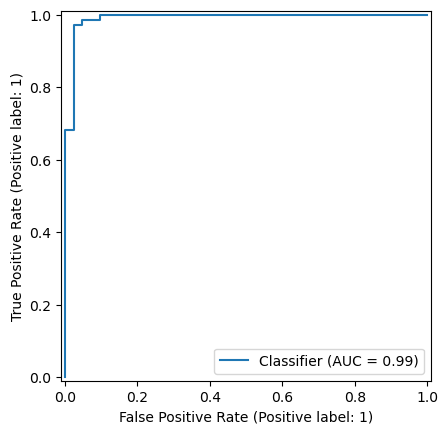

In [69]:
RocCurveDisplay.from_predictions(y_test,y_proba)
plt.show()

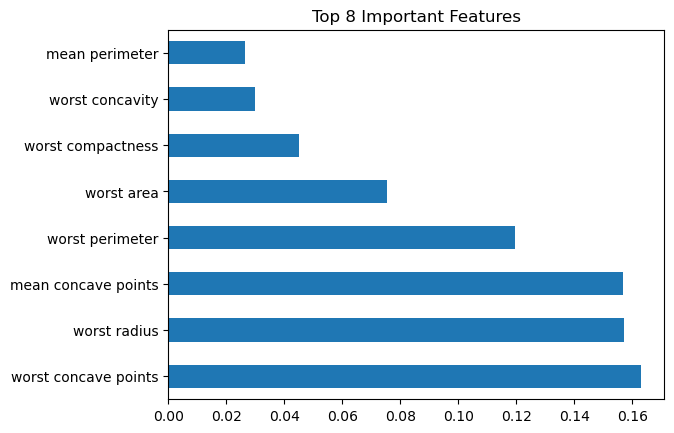

In [75]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(8).plot(kind='barh')
plt.title("Top 8 Important Features")
plt.show()

In [80]:
param_grid={
    'learning_rate':[0.01, 0.05, 0.1 ,0.5],
    'n_estimators':[50, 100, 150, 200, 300],
    'max_depth':[3,4,5],
    'subsample':[0.6, 0.8,1.0],
    'colsample_bytree':[0.6, 0.8,1.0]
}

In [85]:
grid=GridSearchCV(
    estimator=XGBClassifier(eval_metrics='logloss'),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1 #number of jobs in parllel -1 use all processors
)

In [88]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 540 candidates, totalling 1620 fits


/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:15:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:15:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:15:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/shankariseethalaksmimohanakrishnan/miniforge3/envs/ml_env/lib/python3.10/site-packages/xgboost/trai

,estimator,"XGBClassifier...obs=None, ...)"
,param_grid,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [89]:
grid.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.5,
 'max_depth': 4,
 'n_estimators': 100,
 'subsample': 0.6}

In [113]:
best_model=grid.best_estimator_
y_pred=best_model.predict(X_test)
y_proba=best_model.predict_proba(X_test)[:,1]

In [114]:
y_pred


array([1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1])

In [116]:
y_proba.tolist()[:5]

[0.9390004873275757,
 0.99991774559021,
 0.0001365972129860893,
 0.01396340224891901,
 0.9993892908096313]

In [117]:
#Final ROC-AUC
roc_auc_score(y_test,y_proba)

0.9871031746031746